# Analisi del Sentiment – Modello AI (feel-it-italian-emotion)
Notebook autonomo: legge i file Excel e applica il modello NLP italiano
per classificare le emozioni (joy, sadness, anger, fear) nelle risposte.

Sezioni:
- 0–4: installazione, configurazione, modello, funzioni, lettura file
- 5–8: analisi per risposta, riepilogo, distribuzione globale, export CSV
- 10: media emozioni per domanda
- 11: conteggio periodi e caratteri per emozione


## 0. Installazione dipendenze

In [1]:
# Esegui solo la prima volta
!pip install transformers torch openpyxl pandas reportlab matplotlib

  Using cached regex-2026.4.4-cp311-cp311-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached hf_xet-1.4.3-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   - --------------------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Import e configurazione

In [2]:
import re
import os
import pandas as pd
import openpyxl
from pathlib import Path
from collections import defaultdict
from transformers import pipeline

# --- Percorsi ---
CARTELLA_RISPOSTE = Path("risposte")  # sottocartella relativa al notebook
SHEET_NAME        = "PRE_CONS"
N_FILE            = 22

# Colonne (0-based) che contengono domande (riga 1) e risposte (riga 2)
# La struttura è: col 0 = label, poi domande/risposte a coppie ogni 2 colonne
COLONNE_DOMANDE = [1, 3, 5, 7, 9, 11]  # B, D, F, H, J, L

# Emozioni del modello
EMOZIONI = ["joy", "sadness", "anger", "fear"]
EMOJI    = {"joy": "😊", "sadness": "😢", "anger": "😡", "fear": "😨"}

print("✅ Librerie caricate correttamente")

✅ Librerie caricate correttamente


## 2. Caricamento modello

In [3]:
print("Caricamento modello (primo avvio: scarica ~500MB)...")

classifier = pipeline(
    "text-classification",
    model="MilaNLProc/feel-it-italian-emotion",
    top_k=None   # restituisce tutte e 4 le emozioni
)

print("✅ Modello pronto")

Caricamento modello (primo avvio: scarica ~500MB)...
✅ Modello pronto


C:\Users\giugg\OneDrive\Desktop\brondino\DIAGNOSI\sentiment_env\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


## 3. Funzioni di utilità

In [4]:
def split_in_periodi(testo: str, min_len: int = 10) -> list[str]:
    """Divide il testo in corrispondenza dei segni di punteggiatura .?!:;"""
    if not testo or not testo.strip():
        return []
    periodi = re.split(r'[.?!:;]+|\n+', testo)
    return [p.strip() for p in periodi if len(p.strip()) >= min_len]


def analizza_periodi(periodi: list[str]) -> dict:
    """
    Riceve una lista di periodi e restituisce:
      - dettaglio: lista di dict {periodo, emozione_top, score_top, scores}
      - media:     dict {emozione: media_score} — pesata per n. parole del periodo
    """
    if not periodi:
        return {"dettaglio": [], "media": {e: 0.0 for e in EMOZIONI}}

    score_totali = defaultdict(float)
    dettaglio    = []

    for periodo in periodi:
        try:
            risultati = classifier(periodo[:512])[0]   # limite token BERT
        except Exception:
            continue

        scores       = {r["label"]: r["score"] for r in risultati}
        emozione_top = max(scores.items(), key=lambda x: x[1])

        n_caratteri = len(periodo)
        n_parole     = len(periodo.split())

        dettaglio.append({
            "periodo":      periodo,
            "emozione_top": emozione_top[0],
            "score_top":    round(emozione_top[1] * 100, 1),
            "scores":       {e: round(scores.get(e, 0) * 100, 1) for e in EMOZIONI},
            "n_caratteri":  n_caratteri,
            "n_parole":     n_parole
        })

        for e in EMOZIONI:
            score_totali[e] += scores.get(e, 0) * n_parole  # peso = n. parole del periodo

    # Media pesata per lunghezza (n. parole): periodi più lunghi contano di più
    tot_parole_peso = sum(d["n_parole"] for d in dettaglio)
    media = {e: round(score_totali[e] / tot_parole_peso * 100, 1)
             if tot_parole_peso > 0 else 0.0
             for e in EMOZIONI}

    # Spazio testuale pesato: caratteri e parole di ogni periodo
    # distribuiti proporzionalmente agli score delle 4 emozioni
    spazio        = {e: {"caratteri": 0.0, "parole": 0.0} for e in EMOZIONI}
    tot_caratteri = sum(d["n_caratteri"] for d in dettaglio)
    tot_parole    = sum(d["n_parole"]    for d in dettaglio)
    for d in dettaglio:
        score_sum = sum(d["scores"].values())  # somma % (~100)
        if score_sum == 0:
            continue
        for e in EMOZIONI:
            peso = d["scores"][e] / score_sum * 100  # peso in % (0-100)
            spazio[e]["caratteri"] += d["n_caratteri"] * peso / 100
            spazio[e]["parole"]    += d["n_parole"]    * peso / 100
    for e in EMOZIONI:
        spazio[e]["caratteri"] = round(spazio[e]["caratteri"], 1)
        spazio[e]["parole"]    = round(spazio[e]["parole"],    1)
        spazio[e]["perc_car"]  = round(spazio[e]["caratteri"] / tot_caratteri * 100, 1) if tot_caratteri else 0.0
        spazio[e]["perc_par"]  = round(spazio[e]["parole"]    / tot_parole    * 100, 1) if tot_parole    else 0.0

    return {"dettaglio": dettaglio, "media": media,
            "spazio": spazio, "tot_caratteri": tot_caratteri, "tot_parole": tot_parole}


def barra(score, larghezza=20):
    filled = int(score / 100 * larghezza)
    return "█" * filled + "░" * (larghezza - filled)


print("✅ Funzioni definite")

✅ Funzioni definite


## 4. Lettura dei 22 file Excel

In [5]:
def leggi_file(numero: int) -> dict | None:
    """
    Legge il file XX_risposte.xlsx e restituisce un dict con:
      file, domande (lista 6), risposte (lista 6)
    """
    nome_file = CARTELLA_RISPOSTE / f"{numero:02d}_risposte.xlsx"

    if not nome_file.exists():
        print(f"  ⚠️  File non trovato: {nome_file}")
        return None

    try:
        wb = openpyxl.load_workbook(nome_file, read_only=True, data_only=True)

        if SHEET_NAME not in wb.sheetnames:
            print(f"  ⚠️  Foglio '{SHEET_NAME}' non trovato in {nome_file.name}")
            print(f"       Fogli disponibili: {wb.sheetnames}")
            return None

        ws   = wb[SHEET_NAME]
        rows = list(ws.iter_rows(min_row=1, max_row=2, values_only=True))

        if len(rows) < 2:
            print(f"  ⚠️  Il foglio {SHEET_NAME} in {nome_file.name} ha meno di 2 righe")
            return None

        riga_domande  = rows[0]
        riga_risposte = rows[1]

        domande  = []
        risposte = []

        for col in COLONNE_DOMANDE:
            d = riga_domande[col]  if col < len(riga_domande)  else None
            r = riga_risposte[col] if col < len(riga_risposte) else None
            domande.append(str(d).strip() if d else "")
            risposte.append(str(r).strip() if r else "")

        return {
            "file":     nome_file.name,
            "numero":   numero,
            "domande":  domande,
            "risposte": risposte
        }

    except Exception as e:
        print(f"  ❌ Errore leggendo {nome_file.name}: {e}")
        return None


# Carica tutti i file
print(f"Lettura di {N_FILE} file da '{CARTELLA_RISPOSTE}/'...\n")
dati_grezzi = []

for i in range(1, N_FILE + 1):
    dati = leggi_file(i)
    if dati:
        dati_grezzi.append(dati)
        print(f"  ✅ {dati['file']} — {sum(1 for r in dati['risposte'] if r)} risposte trovate")

print(f"\nFile caricati correttamente: {len(dati_grezzi)}/{N_FILE}")

Lettura di 22 file da 'risposte/'...

  ✅ 01_risposte.xlsx — 6 risposte trovate
  ✅ 02_risposte.xlsx — 6 risposte trovate
  ✅ 03_risposte.xlsx — 6 risposte trovate
  ✅ 04_risposte.xlsx — 6 risposte trovate
  ✅ 05_risposte.xlsx — 6 risposte trovate
  ✅ 06_risposte.xlsx — 6 risposte trovate
  ⚠️  File non trovato: risposte\07_risposte.xlsx
  ⚠️  File non trovato: risposte\08_risposte.xlsx
  ✅ 09_risposte.xlsx — 6 risposte trovate
  ✅ 10_risposte.xlsx — 6 risposte trovate
  ⚠️  File non trovato: risposte\11_risposte.xlsx
  ✅ 12_risposte.xlsx — 6 risposte trovate
  ✅ 13_risposte.xlsx — 6 risposte trovate
  ✅ 14_risposte.xlsx — 6 risposte trovate
  ⚠️  File non trovato: risposte\15_risposte.xlsx
  ✅ 16_risposte.xlsx — 6 risposte trovate
  ✅ 17_risposte.xlsx — 6 risposte trovate
  ⚠️  File non trovato: risposte\18_risposte.xlsx
  ⚠️  File non trovato: risposte\19_risposte.xlsx
  ⚠️  File non trovato: risposte\20_risposte.xlsx
  ✅ 21_risposte.xlsx — 6 risposte trovate
  ⚠️  File non trovato: 

## 5. Analisi del sentiment per ogni risposta

In [6]:
risultati_completi = []

for dati in dati_grezzi:
    print(f"\n{'='*60}")
    print(f"📄 File: {dati['file']}")
    print(f"{'='*60}")

    analisi_file = {
        "file":    dati["file"],
        "numero":  dati["numero"],
        "domande": dati["domande"],
        "risposte_analizzate": []
    }

    for idx, (domanda, risposta) in enumerate(zip(dati["domande"], dati["risposte"])):
        print(f"\n  🔹 Domanda {idx+1}: {domanda[:80]}...")

        if not risposta:
            print("     (risposta vuota — salto)")
            analisi_file["risposte_analizzate"].append(None)
            continue

        # Split in periodi
        periodi = split_in_periodi(risposta)
        print(f"     Periodi rilevati: {len(periodi)}")

        # Analisi emotiva
        analisi = analizza_periodi(periodi)

        # Stampa risultati per periodo
        for p in analisi["dettaglio"]:
            top  = p["emozione_top"]
            print(f"\n     [{EMOJI[top]} {top.upper():8s} {p['score_top']:5.1f}%] "
                  f"\"{p['periodo']}\"")
            for e in EMOZIONI:
                marker = " ◄" if e == top else ""
                print(f"       {EMOJI[e]} {e:<10} {barra(p['scores'][e])} "
                      f"{p['scores'][e]:5.1f}%{marker}")

        # Stampa media e spazio testuale per domanda
        sp = analisi["spazio"]
        print(f"\n     ── MEDIA DOMANDA {idx+1} "
              f"(tot: {analisi['tot_parole']} parole / {analisi['tot_caratteri']} caratteri) ──")
        print(f"       {'':12} {'score':>7}  {'parole':>7} {'%par':>6}  {'caratt.':>8} {'%car':>6}")
        print(f"       {'-'*55}")
        for e in EMOZIONI:
            print(f"       {EMOJI[e]} {e:<10} "
                  f"{analisi['media'][e]:6.1f}%  "
                  f"{sp[e]['parole']:>7}  {sp[e]['perc_par']:>5.1f}%  "
                  f"{sp[e]['caratteri']:>8}  {sp[e]['perc_car']:>5.1f}%")

        analisi_file["risposte_analizzate"].append({
            "domanda":       domanda,
            "risposta":      risposta,
            "periodi":       len(periodi),
            "dettaglio":     analisi["dettaglio"],
            "media":         analisi["media"],
            "spazio":        analisi["spazio"],
            "tot_caratteri": analisi["tot_caratteri"],
            "tot_parole":    analisi["tot_parole"]
        })

    risultati_completi.append(analisi_file)

print("\n\n✅ Analisi completata per tutti i file")


📄 File: 01_risposte.xlsx

  🔹 Domanda 1: Q1. Quali sono i motivi che l'hanno portata a cercare un percorso diagnostico in...
     Periodi rilevati: 3

     [😢 SADNESS   99.8%] ""Principalmente perché stavo davvero molto male ed avevo bisogno di aiuto in più aree della mia vita"
       😊 joy        ░░░░░░░░░░░░░░░░░░░░   0.1%
       😢 sadness    ███████████████████░  99.8% ◄
       😡 anger      ░░░░░░░░░░░░░░░░░░░░   0.0%
       😨 fear       ░░░░░░░░░░░░░░░░░░░░   0.1%

     [😢 SADNESS   95.9%] "Mi sono rivolta al cps, anche sotto consiglio della mia psicoterapeuta, perché avevo decisamente bisogno di un supporto farmacologico per l'ansia e la depressione"
       😊 joy        ░░░░░░░░░░░░░░░░░░░░   0.1%
       😢 sadness    ███████████████████░  95.9% ◄
       😡 anger      ░░░░░░░░░░░░░░░░░░░░   0.0%
       😨 fear       ░░░░░░░░░░░░░░░░░░░░   3.9%

     [😢 SADNESS   99.1%] "Allo stesso tempo mi sembrava che le sole diagnosi di depressione ed ansia non spiegassero bene tutte le mie diffi

## 6. Riepilogo complessivo per file

In [7]:
righe = []

for analisi_file in risultati_completi:
    for idx, ra in enumerate(analisi_file["risposte_analizzate"]):
        if ra is None:
            continue
        riga = {
            "file":          analisi_file["file"],
            "numero":        analisi_file["numero"],
            "domanda_n":     idx + 1,
            "domanda":       ra["domanda"][:80],
            "periodi":       ra["periodi"],
            "tot_parole":    ra["tot_parole"],
            "tot_caratteri": ra["tot_caratteri"],
        }
        for e in EMOZIONI:
            riga[f"{e}_score"]        = ra["media"][e]
            riga[f"{e}_parole"]       = ra["spazio"][e]["parole"]
            riga[f"{e}_perc_parole"]  = ra["spazio"][e]["perc_par"]
            riga[f"{e}_caratteri"]    = ra["spazio"][e]["caratteri"]
            riga[f"{e}_perc_caratteri"] = ra["spazio"][e]["perc_car"]
        riga["emozione_top_score"]      = max(EMOZIONI, key=lambda e: ra["media"][e])
        riga["emozione_top_parole"]     = max(EMOZIONI, key=lambda e: ra["spazio"][e]["parole"])
        riga["emozione_top_caratteri"]  = max(EMOZIONI, key=lambda e: ra["spazio"][e]["caratteri"])
        righe.append(riga)

df_riepilogo = pd.DataFrame(righe)
print("Riepilogo complessivo:")
df_riepilogo

Riepilogo complessivo:


,file,numero,domanda_n,domanda,periodi,tot_parole,tot_caratteri,joy_score,joy_parole,joy_perc_parole,...,anger_caratteri,anger_perc_caratteri,fear_score,fear_parole,fear_perc_parole,fear_caratteri,fear_perc_caratteri,emozione_top_score,emozione_top_parole,emozione_top_caratteri
0,01_risposte.xlsx,1,1,Q1. Quali sono i motivi che l'hanno portata a ...,3,92,568,0.1,0.0,0.0,...,0.0,0.0,1.5,1.4,1.5,8.9,1.6,sadness,sadness,sadness
1,01_risposte.xlsx,1,2,Q2. Pensa che una diagnosi potrebbe aiutarla a...,1,28,209,0.0,0.0,0.0,...,194.0,92.8,0.8,0.2,0.7,1.7,0.8,anger,anger,anger
2,01_risposte.xlsx,1,3,Q3. Ci sono aspetti del suo carattere o del su...,4,66,375,20.5,13.5,20.5,...,3.0,0.8,25.9,17.1,25.9,86.5,23.1,sadness,sadness,sadness
3,01_risposte.xlsx,1,4,Q5. Può raccontarci come ha vissuto sul piano ...,7,164,1004,24.0,39.4,24.0,...,2.0,0.2,2.1,3.4,2.1,21.5,2.1,sadness,sadness,sadness
4,01_risposte.xlsx,1,5,Q6. Il confronto con altre persone o altri sti...,7,171,1023,27.5,47.1,27.5,...,0.9,0.1,15.7,26.9,15.7,162.4,15.9,sadness,sadness,sadness
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,21_risposte.xlsx,21,2,Q2. Pensa che una diagnosi potrebbe aiutarla a...,1,38,213,0.1,0.0,0.0,...,0.0,0.0,0.1,0.0,0.0,0.2,0.1,sadness,sadness,sadness
80,21_risposte.xlsx,21,3,Q3. Ci sono aspetti del suo carattere o del su...,4,258,1551,0.0,0.1,0.0,...,23.8,1.5,8.6,22.2,8.6,133.9,8.6,sadness,sadness,sadness
81,21_risposte.xlsx,21,4,Q5. Può raccontarci come ha vissuto sul piano ...,9,360,2058,28.7,103.2,28.7,...,10.9,0.5,8.5,30.5,8.5,173.6,8.4,sadness,sadness,sadness
82,21_risposte.xlsx,21,5,Q6. Il confronto con altre persone o altri sti...,9,360,2058,28.7,103.2,28.7,...,10.9,0.5,8.5,30.5,8.5,173.6,8.4,sadness,sadness,sadness


## 7. Distribuzione emotiva globale (tutti i file, tutte le domande)

In [8]:
print("\n" + "="*70)
print("  DISTRIBUZIONE EMOTIVA GLOBALE")
print("="*70)
print(f"  {'':12} {'score medio':>12}  {'parole':>8} {'%par':>6}  {'caratteri':>10} {'%car':>6}")
print(f"  {'-'*65}")

for e in EMOZIONI:
    score_medio = df_riepilogo[f"{e}_score"].mean()
    tot_par     = df_riepilogo[f"{e}_parole"].sum()
    tot_car     = df_riepilogo[f"{e}_caratteri"].sum()
    tot_par_all = df_riepilogo["tot_parole"].sum()
    tot_car_all = df_riepilogo["tot_caratteri"].sum()
    perc_par    = round(tot_par / tot_par_all * 100, 1) if tot_par_all else 0
    perc_car    = round(tot_car / tot_car_all * 100, 1) if tot_car_all else 0
    print(f"  {EMOJI[e]} {e:<10} {score_medio:>11.1f}%  {tot_par:>8}  {perc_par:>5.1f}%  {tot_car:>10}  {perc_car:>5.1f}%")

print("\nEmozione top per score:")
print(df_riepilogo["emozione_top_score"].value_counts())
print("\nEmozione top per parole dedicate:")
print(df_riepilogo["emozione_top_parole"].value_counts())
print("\nEmozione top per caratteri dedicati:")
print(df_riepilogo["emozione_top_caratteri"].value_counts())


  DISTRIBUZIONE EMOTIVA GLOBALE
                score medio    parole   %par   caratteri   %car
  -----------------------------------------------------------------
  😊 joy               24.3%    1162.0   18.6%      7195.8   18.5%
  😢 sadness           52.0%  3634.9000000000005   58.1%  22266.600000000002   57.4%
  😡 anger              4.6%  220.90000000000003    3.5%      1455.2    3.8%
  😨 fear              19.1%    1239.6   19.8%  7884.800000000001   20.3%

Emozione top per score:
emozione_top_score
sadness    48
joy        18
fear       15
anger       3
Name: count, dtype: int64

Emozione top per parole dedicate:
emozione_top_parole
sadness    48
joy        18
fear       15
anger       3
Name: count, dtype: int64

Emozione top per caratteri dedicati:
emozione_top_caratteri
sadness    48
joy        18
fear       15
anger       3
Name: count, dtype: int64


## 8. Esporta riepilogo in CSV e PDF analisi per risposta

In [9]:
# ── Export CSV ──────────────────────────────────────────────────────────────
output_csv = "riepilogo_sentiment.csv"
df_riepilogo.to_csv(output_csv, index=False, encoding="utf-8-sig")
print(f"✅ CSV salvato in '{output_csv}'")

# ── Export PDF con gli output del punto 5 ───────────────────────────────────
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, HRFlowable, Table, TableStyle
from reportlab.lib.enums import TA_LEFT, TA_CENTER

output_pdf = "analisi_sentiment_risposte.pdf"
doc = SimpleDocTemplate(
    output_pdf,
    pagesize=A4,
    leftMargin=2*cm, rightMargin=2*cm,
    topMargin=2*cm, bottomMargin=2*cm
)

styles = getSampleStyleSheet()
s_titolo    = ParagraphStyle("titolo",    parent=styles["Heading1"], fontSize=14, spaceAfter=6)
s_file      = ParagraphStyle("file",      parent=styles["Heading2"], fontSize=12, spaceAfter=4, textColor=colors.HexColor("#2c3e50"))
s_domanda   = ParagraphStyle("domanda",   parent=styles["Heading3"], fontSize=10, spaceAfter=3, textColor=colors.HexColor("#34495e"))
s_periodo   = ParagraphStyle("periodo",   parent=styles["Normal"],   fontSize=9,  spaceAfter=2, leftIndent=10)
s_testo     = ParagraphStyle("testo",     parent=styles["Normal"],   fontSize=8,  spaceAfter=6, leftIndent=10, textColor=colors.HexColor("#555555"))
s_media     = ParagraphStyle("media",     parent=styles["Normal"],   fontSize=8,  spaceAfter=8, leftIndent=10, textColor=colors.HexColor("#1a5276"))

COLORI_EMO = {"joy": "#f4c542", "sadness": "#4a90d9", "anger": "#e05252", "fear": "#9b59b6"}

elementi = [Paragraph("Analisi Sentiment – Modello AI (feel-it-italian-emotion)", s_titolo)]

for analisi_file in risultati_completi:
    elementi.append(Spacer(1, 0.3*cm))
    elementi.append(HRFlowable(width="100%", thickness=1.5, color=colors.HexColor("#2c3e50")))
    elementi.append(Paragraph(f"📄 {analisi_file['file']}", s_file))

    for idx, ra in enumerate(analisi_file["risposte_analizzate"]):
        if ra is None:
            continue

        elementi.append(Paragraph(f"Domanda {idx+1}: {ra['domanda'][:100]}", s_domanda))
        elementi.append(Paragraph(
            f"Periodi: {ra['periodi']} | Parole: {ra['tot_parole']} | Caratteri: {ra['tot_caratteri']}",
            s_testo
        ))

        # Dettaglio periodi
        for p in ra["dettaglio"]:
            top = p["emozione_top"]
            colore = colors.HexColor(COLORI_EMO[top])
            label = f"{EMOJI[top]} {top.upper()} {p['score_top']:.1f}%"
            elementi.append(Paragraph(
                f'<font color="{COLORI_EMO[top]}"><b>[{label}]</b></font> {p["periodo"]}',
                s_periodo
            ))
            score_riga = "  ".join(
                f"{EMOJI[e]} {e}: {p['scores'][e]:.1f}%" for e in EMOZIONI
            )
            elementi.append(Paragraph(score_riga, s_testo))

        # Tabella media per domanda
        sp = ra["spazio"]
        intestazione = ["Emozione", "Score medio", "Parole", "% parole", "Caratteri", "% caratteri"]
        dati_tab = [intestazione] + [
            [
                f"{EMOJI[e]} {e}",
                f"{ra['media'][e]:.1f}%",
                f"{sp[e]['parole']}",
                f"{sp[e]['perc_par']:.1f}%",
                f"{sp[e]['caratteri']}",
                f"{sp[e]['perc_car']:.1f}%"
            ]
            for e in EMOZIONI
        ]
        t = Table(dati_tab, colWidths=[3*cm, 2.5*cm, 2*cm, 2*cm, 2.5*cm, 2.5*cm])
        t.setStyle(TableStyle([
            ("BACKGROUND",   (0,0), (-1,0),  colors.HexColor("#2c3e50")),
            ("TEXTCOLOR",    (0,0), (-1,0),  colors.white),
            ("FONTSIZE",     (0,0), (-1,-1), 7.5),
            ("ALIGN",        (1,0), (-1,-1), "CENTER"),
            ("ROWBACKGROUNDS",(0,1),(-1,-1), [colors.HexColor("#f2f3f4"), colors.white]),
            ("GRID",         (0,0), (-1,-1), 0.4, colors.HexColor("#cccccc")),
            ("TOPPADDING",   (0,0), (-1,-1), 3),
            ("BOTTOMPADDING",(0,0), (-1,-1), 3),
        ]))
        elementi.append(Spacer(1, 0.2*cm))
        elementi.append(t)
        elementi.append(Spacer(1, 0.4*cm))

doc.build(elementi)
print(f"✅ PDF salvato in '{output_pdf}'")

✅ CSV salvato in 'riepilogo_sentiment.csv'
✅ PDF salvato in 'analisi_sentiment_risposte.pdf'


## 10. Media delle emozioni per domanda (tutte le risposte)
Per ogni domanda (1–6) calcola la media degli score emotivi aggregando tutti i 22 file.

  MEDIA EMOZIONI PER DOMANDA (aggregato su tutti i file)
    Domanda  😊 joy         😢 sadness     😡 anger       😨 fear      
  -----------------------------------------------------------------
  Domanda  1:    14.9%           61.7%            1.9%           21.6%         
  Domanda  2:    19.5%           53.6%            9.6%           17.3%         
  Domanda  3:     5.2%           60.6%            9.5%           24.7%         
  Domanda  4:    35.5%           53.6%            0.2%           10.7%         
  Domanda  5:    33.8%           38.2%            3.7%           24.3%         
  Domanda  6:    37.1%           44.1%            2.8%           16.0%         
Emozione prevalente per domanda:
    Domanda 1: 😢 Sadness (61.7%)
    Domanda 2: 😢 Sadness (53.6%)
    Domanda 3: 😢 Sadness (60.6%)
    Domanda 4: 😢 Sadness (53.6%)
    Domanda 5: 😢 Sadness (38.2%)
    Domanda 6: 😢 Sadness (44.1%)


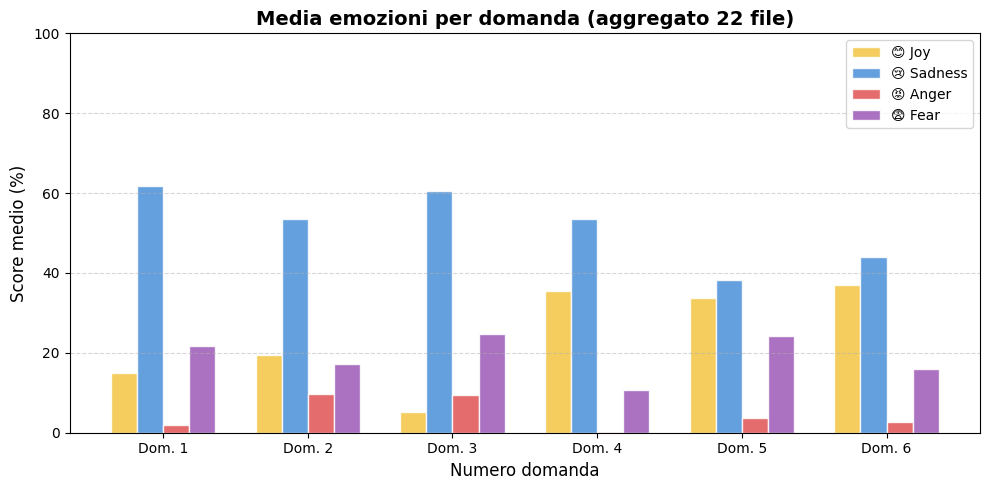

✅ Grafico salvato in 'media_emozioni_per_domanda.png'
✅ Tabella salvata in 'media_emozioni_per_domanda.csv'


In [10]:
# ── Media delle 4 emozioni per ogni domanda ────────────────────────────────

print("" + "="*70)
print("  MEDIA EMOZIONI PER DOMANDA (aggregato su tutti i file)")
print("="*70)

# df_riepilogo contiene una riga per ogni (file, domanda)
# raggruppiamo per numero di domanda e calcoliamo la media degli score
media_per_domanda = (
    df_riepilogo
    .groupby("domanda_n")[[f"{e}_score" for e in EMOZIONI]]
    .mean()
    .round(1)
)
media_per_domanda.columns = [e.capitalize() for e in EMOZIONI]

# Stampa tabella testuale
label_domanda = 'Domanda'
header = f"  {label_domanda:>9}  " + "  ".join(f"{EMOJI[e]} {e:<10}" for e in EMOZIONI)
print(header)
print("  " + "-" * (len(header) - 2))

for dom_n, row in media_per_domanda.iterrows():
    testo = f"  Domanda {dom_n:>2}:  "
    for e in EMOZIONI:
        val = row[e.capitalize()]
        testo += f"{val:>6.1f}%  ".ljust(16)
    print(testo)

# Emozione prevalente per ogni domanda
print("Emozione prevalente per domanda:")
for dom_n, row in media_per_domanda.iterrows():
    top_e = row.idxmax()
    top_v = row.max()
    e_lower = top_e.lower()
    emoji_top = EMOJI.get(e_lower, '')
    print(f"    Domanda {dom_n}: {emoji_top} {top_e} ({top_v:.1f}%)")

# Visualizzazione grafica con matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 5))
x = media_per_domanda.index  # 1..6
width = 0.18
colors = {"joy": "#f4c542", "sadness": "#4a90d9", "anger": "#e05252", "fear": "#9b59b6"}
offsets = [-1.5, -0.5, 0.5, 1.5]

for i, e in enumerate(EMOZIONI):
    vals = media_per_domanda[e.capitalize()]
    ax.bar([xi + offsets[i] * width for xi in x], vals,
           width=width, label=f"{EMOJI[e]} {e.capitalize()}",
           color=colors[e], alpha=0.85, edgecolor="white")

ax.set_xlabel("Numero domanda", fontsize=12)
ax.set_ylabel("Score medio (%)", fontsize=12)
ax.set_title("Media emozioni per domanda (aggregato 22 file)", fontsize=14, fontweight="bold")
ax.set_xticks(list(x))
ax.set_xticklabels([f"Dom. {i}" for i in x])
ax.legend(loc="upper right")
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("media_emozioni_per_domanda.png", dpi=150)
plt.show()
print("✅ Grafico salvato in 'media_emozioni_per_domanda.png'")

# Export CSV
media_per_domanda.to_csv("media_emozioni_per_domanda.csv", encoding="utf-8-sig")
print("✅ Tabella salvata in 'media_emozioni_per_domanda.csv'")


## 11. Conteggio caratteri, parole ed espressioni (periodi) per emozione
Per ogni emozione conta: numero totale di **periodi** classificati come prevalenti dal modello AI; **parole** e **caratteri** sono distribuiti proporzionalmente agli score delle 4 emozioni (conteggio pesato), aggregati su tutti i file e tutte le domande.

  CONTEGGIO PERIODI, PAROLE E CARATTERI PER EMOZIONE (pesati per score)
  N.B. Parole e caratteri sono distribuiti proporzionalmente agli score del modello
                 Periodi  % periodi    Parole  % parole    Caratteri  % caratteri
  ------------------------------------------------------------------------------
  😊 joy               62       23.4%      1162      18.6%         7196         18.5%
  😢 sadness          146       55.1%      3635      58.1%        22267         57.4%
  😡 anger             11        4.2%       221       3.5%         1455          3.7%
  😨 fear              46       17.4%      1240      19.8%         7885         20.3%
  ------------------------------------------------------------------------------
  TOTALE             265      100.0%      6258     100.0%        38803        100.0%


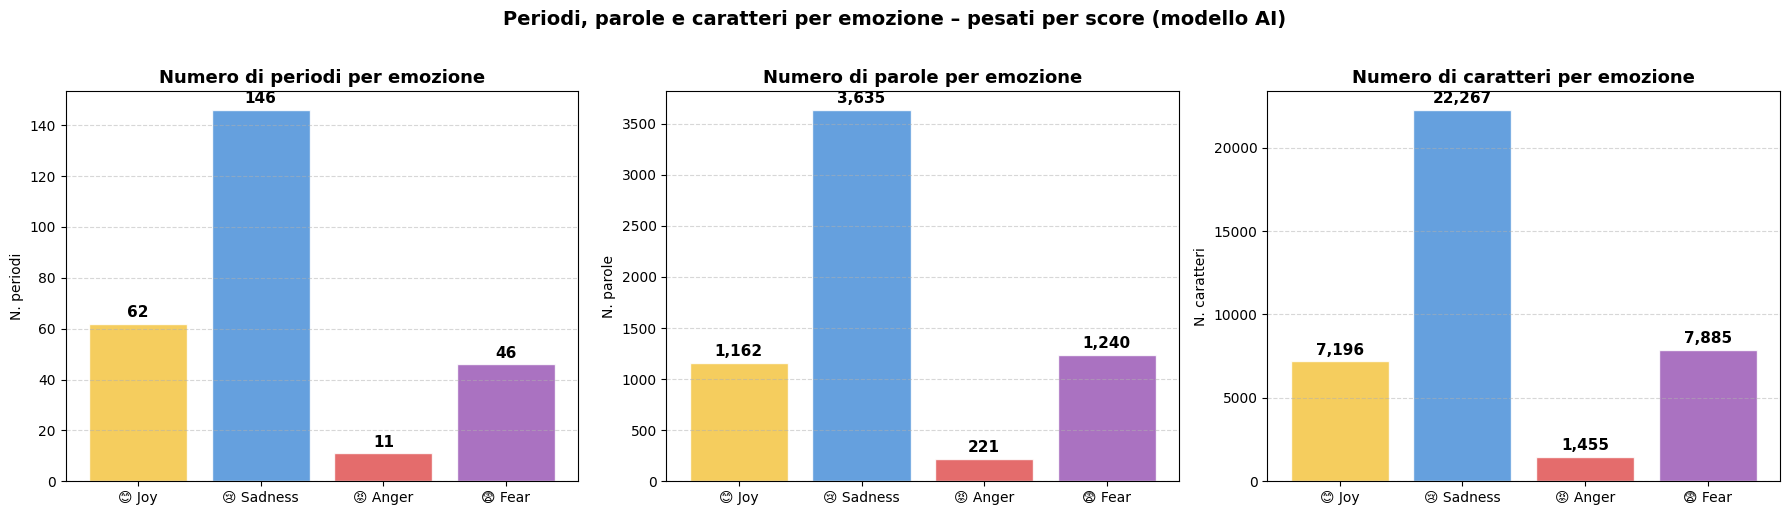

✅ Grafico salvato in 'conteggio_periodi_parole_caratteri_emozione.png'
✅ Tabella salvata in 'conteggio_periodi_parole_caratteri_emozione.csv'


In [11]:
# ── Conteggio periodi e spazio testuale pesato per emozione ────────────────

from collections import defaultdict

conteggio = {e: {"periodi": 0, "caratteri": 0.0, "parole": 0.0} for e in EMOZIONI}

for analisi_file in risultati_completi:
    for ra in analisi_file["risposte_analizzate"]:
        if ra is None:
            continue
        for d in ra["dettaglio"]:
            # periodi: attribuiti all'emozione top (conteggio discreto)
            conteggio[d["emozione_top"]]["periodi"] += 1
            # caratteri e parole: distribuiti proporzionalmente agli score
            score_sum = sum(d["scores"].values())  # somma % (~100)
            if score_sum == 0:
                continue
            for e in EMOZIONI:
                peso = d["scores"][e] / score_sum  # peso proporzionale, i /100 si cancellano
                conteggio[e]["caratteri"] += d["n_caratteri"] * peso
                conteggio[e]["parole"]    += d["n_parole"]    * peso

# Arrotonda i valori pesati
for e in EMOZIONI:
    conteggio[e]["caratteri"] = round(conteggio[e]["caratteri"])
    conteggio[e]["parole"]    = round(conteggio[e]["parole"])

tot_periodi   = sum(v["periodi"]   for v in conteggio.values())
tot_caratteri = sum(v["caratteri"] for v in conteggio.values())
tot_parole    = sum(v["parole"]    for v in conteggio.values())

# ── Stampa tabella ──────────────────────────────────────────────────────────
print("" + "="*70)
print("  CONTEGGIO PERIODI, PAROLE E CARATTERI PER EMOZIONE (pesati per score)")
print("  N.B. Parole e caratteri sono distribuiti proporzionalmente agli score del modello")
print("="*70)
print(f"  {'':12} {'Periodi':>9} {'% periodi':>10}  {'Parole':>8} {'% parole':>9}  {'Caratteri':>11} {'% caratteri':>12}")
print("  " + "-"*78)

for e in EMOZIONI:
    p  = conteggio[e]["periodi"]
    pa = conteggio[e]["parole"]
    c  = conteggio[e]["caratteri"]
    pp = round(p  / tot_periodi   * 100, 1) if tot_periodi   else 0
    ppa= round(pa / tot_parole    * 100, 1) if tot_parole    else 0
    pc = round(c  / tot_caratteri * 100, 1) if tot_caratteri else 0
    print(f"  {EMOJI[e]} {e:<10} {p:>9}  {pp:>9.1f}%  {pa:>8}  {ppa:>8.1f}%  {c:>11}  {pc:>11.1f}%")

print("  " + "-"*78)
print(f"  {'TOTALE':<12} {tot_periodi:>9}  {'100.0':>9}%  {tot_parole:>8}  {'100.0':>8}%  {tot_caratteri:>11}  {'100.0':>11}%")

# ── Grafico ─────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

colors = {"joy": "#f4c542", "sadness": "#4a90d9", "anger": "#e05252", "fear": "#9b59b6"}
labels  = [f"{EMOJI[e]} {e.capitalize()}" for e in EMOZIONI]
periodi_vals   = [conteggio[e]["periodi"]   for e in EMOZIONI]
parole_vals    = [conteggio[e]["parole"]    for e in EMOZIONI]
caratteri_vals = [conteggio[e]["caratteri"] for e in EMOZIONI]
bar_colors = [colors[e] for e in EMOZIONI]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

bars1 = ax1.bar(labels, periodi_vals, color=bar_colors, alpha=0.85, edgecolor="white")
ax1.set_title("Numero di periodi per emozione", fontsize=13, fontweight="bold")
ax1.set_ylabel("N. periodi")
ax1.grid(axis="y", linestyle="--", alpha=0.5)
for bar, val in zip(bars1, periodi_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(periodi_vals)*0.01,
             str(val), ha="center", va="bottom", fontsize=11, fontweight="bold")

bars2 = ax2.bar(labels, parole_vals, color=bar_colors, alpha=0.85, edgecolor="white")
ax2.set_title("Numero di parole per emozione", fontsize=13, fontweight="bold")
ax2.set_ylabel("N. parole")
ax2.grid(axis="y", linestyle="--", alpha=0.5)
for bar, val in zip(bars2, parole_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(parole_vals)*0.01,
             f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")

bars3 = ax3.bar(labels, caratteri_vals, color=bar_colors, alpha=0.85, edgecolor="white")
ax3.set_title("Numero di caratteri per emozione", fontsize=13, fontweight="bold")
ax3.set_ylabel("N. caratteri")
ax3.grid(axis="y", linestyle="--", alpha=0.5)
for bar, val in zip(bars3, caratteri_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(caratteri_vals)*0.01,
             f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.suptitle("Periodi, parole e caratteri per emozione – pesati per score (modello AI)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("conteggio_periodi_parole_caratteri_emozione.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grafico salvato in 'conteggio_periodi_parole_caratteri_emozione.png'")

# ── Export CSV ──────────────────────────────────────────────────────────────
import pandas as pd
df_conteggio = pd.DataFrame([
    {
        "emozione":       e,
        "periodi":        conteggio[e]["periodi"],
        "perc_periodi":   round(conteggio[e]["periodi"]    / tot_periodi   * 100, 1) if tot_periodi   else 0,
        "parole":         conteggio[e]["parole"],
        "perc_parole":    round(conteggio[e]["parole"]     / tot_parole    * 100, 1) if tot_parole    else 0,
        "caratteri":      conteggio[e]["caratteri"],
        "perc_caratteri": round(conteggio[e]["caratteri"] / tot_caratteri * 100, 1) if tot_caratteri else 0,
    }
    for e in EMOZIONI
])
df_conteggio.to_csv("conteggio_periodi_parole_caratteri_emozione.csv", index=False, encoding="utf-8-sig")
print("✅ Tabella salvata in 'conteggio_periodi_parole_caratteri_emozione.csv'")
